# Welcome to Colab!

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os
for f in os.listdir('/content/drive/MyDrive'):
    print(f)

archive (1).zip
Colab Notebooks


In [5]:
import zipfile, os

zip_path = '/content/drive/MyDrive/archive (1).zip'  # update if it's in a subfolder

if not os.path.exists(zip_path):
    raise FileNotFoundError(f"Couldn't find {zip_path} — check the path and try again.")

print(f'Found: {zip_path} ({os.path.getsize(zip_path) / 1e9:.2f} GB)')

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/data')

print('Extraction complete!')

Found: /content/drive/MyDrive/archive (1).zip (3.59 GB)
Extraction complete!


In [7]:
import os
for root, dirs, fls in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    if level > 3:
        continue
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 2:
        print(f'{indent}  ({len(fls)} files)')

data/
  repository/
    yiweichen04-retina_dataset-914b0f4/
      (1 files)
      dataset/
  dataset/
    1_normal/
      (300 files)
    2_cataract/
      (100 files)
    2_glaucoma/
      (101 files)
    3_retina_disease/
      (100 files)


In [8]:
DATA_DIR = ''  # <-- CHANGE THIS if needed based on Step 2 output
CLASSES  = ['normal', 'cataract']
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20
SEED = 42

# Quick check
for c in CLASSES:
    path = os.path.join(DATA_DIR, c)
    if os.path.isdir(path):
        print(f'OK  {c}: {len(os.listdir(path))} images found')
    else:
        print(f'NOT FOUND: {path}  <-- fix DATA_DIR above')

NOT FOUND: normal  <-- fix DATA_DIR above
NOT FOUND: cataract  <-- fix DATA_DIR above


In [10]:
import os
for item in os.listdir('/content/data'):
    print(item)

README.md
repository
dataset


In [11]:
import os
for item in os.listdir('/content/data/dataset'):
    print(item)

1_normal
2_cataract
2_glaucoma
3_retina_disease


In [12]:
DATA_DIR = '/content/data/dataset'  # <-- CHANGE THIS if needed based on Step 2 output
CLASSES  = ['normal', 'cataract']
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20
SEED = 42

# Quick check
for c in CLASSES:
    path = os.path.join(DATA_DIR, c)
    if os.path.isdir(path):
        print(f'OK  {c}: {len(os.listdir(path))} images found')
    else:
        print(f'NOT FOUND: {path}  <-- fix DATA_DIR above')

NOT FOUND: /content/data/dataset/normal  <-- fix DATA_DIR above
NOT FOUND: /content/data/dataset/cataract  <-- fix DATA_DIR above


In [14]:
DATA_DIR = '/content/data/dataset'

# Only use these two folders for binary classification
CLASSES = ['1_normal', '2_cataract']

import os
for c in CLASSES:
    path = os.path.join(DATA_DIR, c)
    print(f'{c}: {len(os.listdir(path))} images')

1_normal: 300 images
2_cataract: 100 images


In [15]:
!pip install -q opencv-python-headless seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))
print('All libraries loaded successfully!')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All libraries loaded successfully!


In [16]:
def load_dataset(data_dir, classes, img_size):
    images, labels = [], []
    for label_idx, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        file_list = sorted(os.listdir(class_dir))
        count = 0
        for fname in file_list:
            fpath = os.path.join(class_dir, fname)
            img = cv2.imread(fpath)        # Load as BGR
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))  # Resize to 224x224
            images.append(img)
            labels.append(label_idx)
            count += 1
        print(f'Loaded {count} images for class: {class_name}')
    return np.array(images), np.array(labels)

X, y = load_dataset(DATA_DIR, CLASSES, IMG_SIZE)
print()
print('Total images:', X.shape[0])
print('Image shape (H x W x Channels):', X.shape[1:])

Loaded 300 images for class: 1_normal
Loaded 100 images for class: 2_cataract

Total images: 400
Image shape (H x W x Channels): (224, 224, 3)


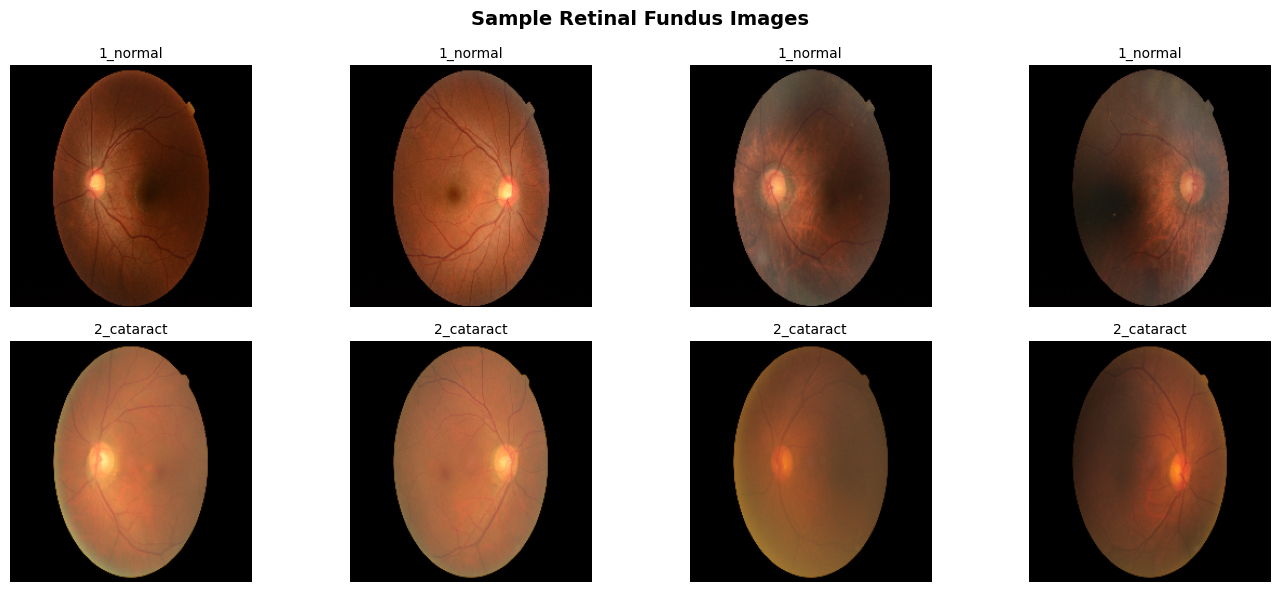

Saved: sample_images.png


In [17]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Sample Retinal Fundus Images', fontsize=14, fontweight='bold')

for i, c in enumerate(CLASSES):
    idxs = np.where(y == i)[0][:4]
    for j, idx in enumerate(idxs):
        ax = axes[i, j]
        ax.imshow(cv2.cvtColor(X[idx], cv2.COLOR_BGR2RGB))
        ax.set_title(c.capitalize(), fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_images.png')

In [18]:
# Normalise pixel values from [0,255] to [0,1]
X_norm = X.astype('float32') / 255.0

# One-hot encode labels
y_cat = to_categorical(y, num_classes=len(CLASSES))

# 80% train, 20% test — stratified so both classes are balanced in each split
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_cat,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 320
Testing  samples : 80


In [20]:
# Load VGG19 pretrained on ImageNet, without the top classification layers
base_model = VGG19(weights='imagenet',
                   include_top=False,
                   input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze all convolutional layers — we only train our new classification head
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(CLASSES), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,463,746 (100.95 MB)

 Trainable params: 6,439,362 (24.56 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1)

print('\nTraining complete!')

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 217ms/step - accuracy: 0.6719 - loss: 0.6977 - val_accuracy: 0.7500 - val_loss: 0.4940
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.7625 - loss: 0.5169 - val_accuracy: 0.7625 - val_loss: 0.4225
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.7563 - loss: 0.4698 - val_accuracy: 0.8875 - val_loss: 0.3543
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.8281 - loss: 0.4069 - val_accuracy: 0.8875 - val_loss: 0.3385
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.8344 - loss: 0.3758 - val_accuracy: 0.8875 - val_loss: 0.2959
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.8500 - loss: 0.3327 - val_accuracy: 0.9000 - val_loss: 0.2782
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.8594 - loss: 0.3354 - val_accuracy: 0.9000 - val_loss: 0.2861
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.8687 - loss: 0.3064 - val_accuracy: 0

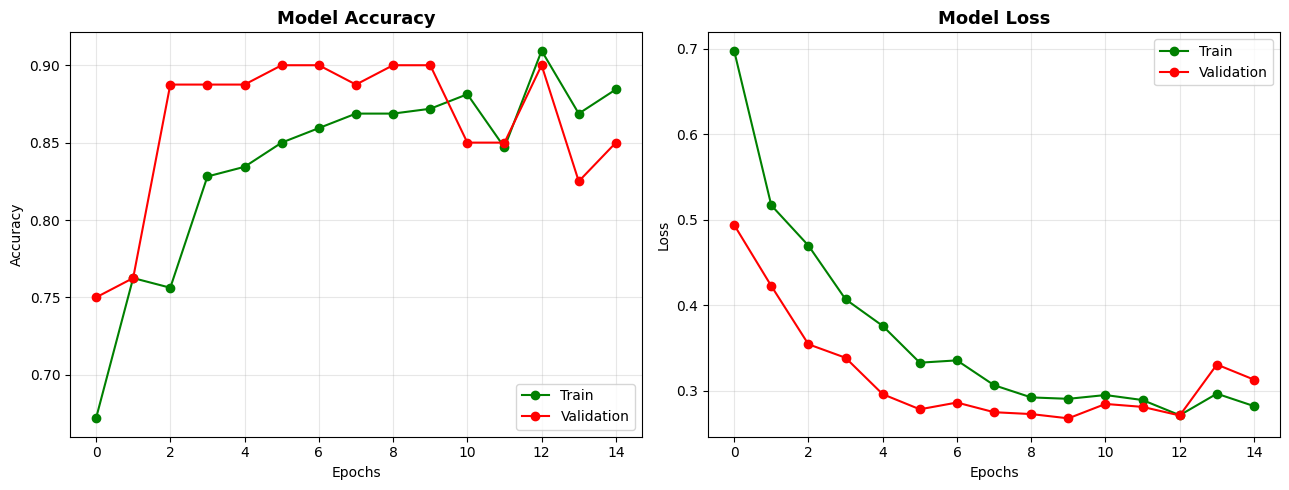

Saved: accuracy_loss_curves.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['accuracy'],     marker='o', label='Train',      color='green')
axes[0].plot(history.history['val_accuracy'], marker='o', label='Validation', color='red')
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     marker='o', label='Train',      color='green')
axes[1].plot(history.history['val_loss'], marker='o', label='Validation', color='red')
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: accuracy_loss_curves.png')

In [23]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test,       axis=1)

test_acc = accuracy_score(y_true, y_pred)

print('=' * 50)
print(f'TEST ACCURACY: {test_acc:.4f}  ({test_acc*100:.2f}%)')
print('=' * 50)
print()
print('CLASSIFICATION REPORT:')
print(classification_report(y_true, y_pred, target_names=CLASSES))

3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 506ms/step
TEST ACCURACY: 0.9000  (90.00%)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    1_normal       0.92      0.95      0.93        60
  2_cataract       0.83      0.75      0.79        20

    accuracy                           0.90        80
   macro avg       0.88      0.85      0.86        80
weighted avg       0.90      0.90      0.90        80



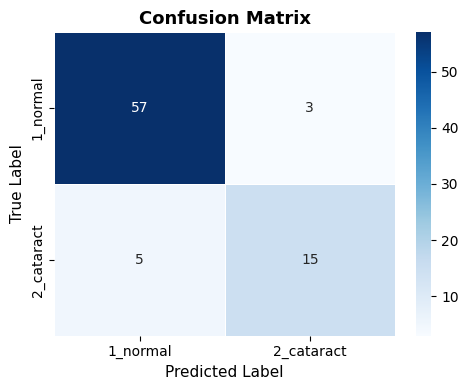

Saved: confusion_matrix.png


In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=CLASSES,
            yticklabels=CLASSES,
            linewidths=0.5)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label',      fontsize=11)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

In [25]:
model.save('cataract_vgg19_model.h5')
print('Model saved!')

from google.colab import files
print('Downloading files to your computer...')
files.download('cataract_vgg19_model.h5')
files.download('accuracy_loss_curves.png')
files.download('confusion_matrix.png')
files.download('sample_images.png')
print('Done! Check your Downloads folder.')

Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Check your Downloads folder.
